# Hypothesis Testing — Weekly Operating Cost Model
**Company:** Bombay Hospitality Ltd.  
**Objective:** Investigate whether the restaurant owners' claim about higher-than-expected weekly operating costs is statistically supported using a Z-test.

---
## 0. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded.')

Libraries loaded.


---
## Problem Setup

In [2]:
# Given data
X_mean   = 600      # Mean units produced per week
X_std    = 25       # Std deviation of units produced
n        = 25       # Sample size (restaurants)
x_bar    = 3050     # Sample mean weekly cost (Rs.)
alpha    = 0.05     # Significance level

# Theoretical cost model: W = 1000 + 5X
# Theoretical mean weekly cost when X = 600
mu_theoretical = 1000 + 5 * X_mean

# Std deviation of weekly cost: σ_W = 5 * σ_X  (linear transformation)
sigma_W = 5 * X_std

print('===== Problem Parameters =====')
print(f'Cost Model             : W = 1,000 + 5X')
print(f'Mean units (μ_X)       : {X_mean} units/week')
print(f'Std dev (σ_X)          : {X_std} units')
print(f'Theoretical mean cost  : W = 1,000 + 5×{X_mean} = Rs. {mu_theoretical:,}')
print(f'Std dev of cost (σ_W)  : 5 × {X_std} = Rs. {sigma_W}')
print(f'Sample size (n)        : {n} restaurants')
print(f'Sample mean (x̄)        : Rs. {x_bar:,}')
print(f'Significance level (α) : {alpha}')

===== Problem Parameters =====
Cost Model             : W = 1,000 + 5X
Mean units (μ_X)       : 600 units/week
Std dev (σ_X)          : 25 units
Theoretical mean cost  : W = 1,000 + 5×600 = Rs. 4,000
Std dev of cost (σ_W)  : 5 × 25 = Rs. 125
Sample size (n)        : 25 restaurants
Sample mean (x̄)        : Rs. 3,050
Significance level (α) : 0.05


---
## Task 1 — State the Hypotheses

In [3]:
print('=' * 65)
print('HYPOTHESES  (One-Tailed Right Test)')
print('=' * 65)
print()
print('H₀ (Null Hypothesis):')
print(f'   The mean weekly operating cost is equal to the')
print(f'   theoretical model cost.')
print(f'   H₀ : μ = Rs. {mu_theoretical:,}')
print()
print('H₁ (Alternative Hypothesis):')
print(f'   The mean weekly operating cost is GREATER than the')
print(f'   theoretical model cost (restaurant owners claim costs are higher).')
print(f'   H₁ : μ > Rs. {mu_theoretical:,}')
print()
print('Test Type  : One-tailed (right-tailed) Z-test')
print(f'Alpha (α)  : {alpha}')

HYPOTHESES  (One-Tailed Right Test)

H₀ (Null Hypothesis):
   The mean weekly operating cost is equal to the
   theoretical model cost.
   H₀ : μ = Rs. 4,000

H₁ (Alternative Hypothesis):
   The mean weekly operating cost is GREATER than the
   theoretical model cost (restaurant owners claim costs are higher).
   H₁ : μ > Rs. 4,000

Test Type  : One-tailed (right-tailed) Z-test
Alpha (α)  : 0.05


---
## Task 2 — Calculate the Test Statistic

In [4]:
# Standard Error = σ_W / sqrt(n)
SE = sigma_W / np.sqrt(n)

# Z = (x̄ - μ) / SE
Z_stat = (x_bar - mu_theoretical) / SE

print('===== Test Statistic Calculation =====')
print()
print('Formula:  Z = (x̄ − μ) / (σ_W / √n)')
print()
print(f'  x̄          = Rs. {x_bar:,}  (sample mean)')
print(f'  μ           = Rs. {mu_theoretical:,}  (theoretical mean from model)')
print(f'  σ_W         = 5 × {X_std} = {sigma_W}  (std dev of weekly cost)')
print(f'  n           = {n}')
print(f'  √n          = {np.sqrt(n):.4f}')
print(f'  SE = σ/√n   = {sigma_W} / {np.sqrt(n):.4f} = {SE:.4f}')
print()
print(f'  Z = ({x_bar} − {mu_theoretical}) / {SE:.4f}')
print(f'    = {x_bar - mu_theoretical} / {SE:.4f}')
print(f'    = {Z_stat:.4f}')
print()
print(f'Z Test Statistic = {Z_stat:.4f}')

===== Test Statistic Calculation =====

Formula:  Z = (x̄ − μ) / (σ_W / √n)

  x̄          = Rs. 3,050  (sample mean)
  μ           = Rs. 4,000  (theoretical mean from model)
  σ_W         = 5 × 25 = 125  (std dev of weekly cost)
  n           = 25
  √n          = 5.0000
  SE = σ/√n   = 125 / 5.0000 = 25.0000

  Z = (3050 − 4000) / 25.0000
    = -950 / 25.0000
    = -38.0000

Z Test Statistic = -38.0000


---
## Task 3 — Determine the Critical Value

In [5]:
# One-tailed right test: critical value at alpha = 0.05
Z_critical = stats.norm.ppf(1 - alpha)
p_value    = 1 - stats.norm.cdf(Z_stat)   # right-tailed p-value

print('===== Critical Value =====')
print()
print(f'Test Type          : One-tailed (right-tailed)')
print(f'Significance Level : α = {alpha}')
print(f'Critical Value     : Z_crit = {Z_critical:.4f}')
print(f'P-value            : {p_value:.6f}')
print()
print(f'→ Reject H₀ if Z_stat > {Z_critical:.4f}')

===== Critical Value =====

Test Type          : One-tailed (right-tailed)
Significance Level : α = 0.05
Critical Value     : Z_crit = 1.6449
P-value            : 1.000000

→ Reject H₀ if Z_stat > 1.6449


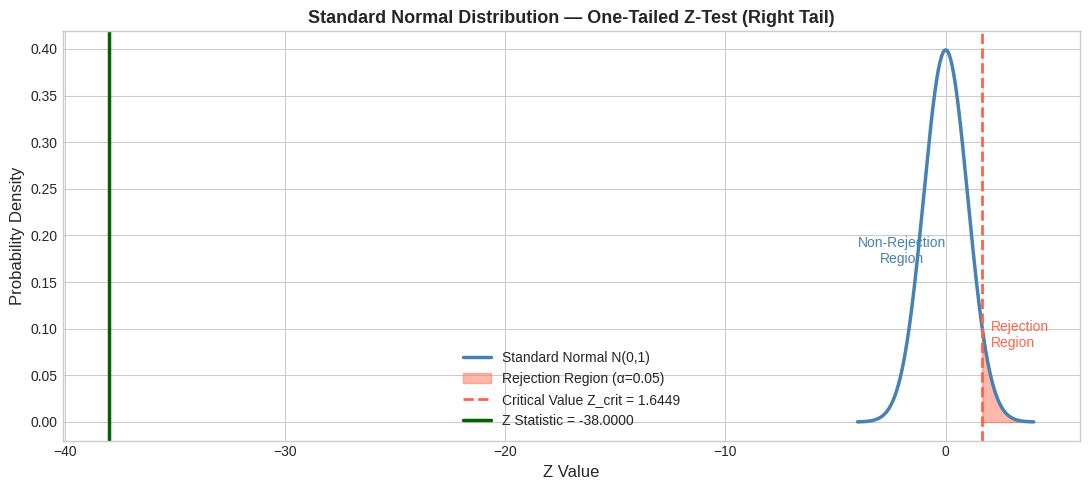

In [6]:
# Standard normal distribution with rejection region
x_range = np.linspace(-4, 4, 500)
y_norm  = stats.norm.pdf(x_range)

plt.figure(figsize=(11, 5))
plt.plot(x_range, y_norm, color='steelblue', linewidth=2.5, label='Standard Normal N(0,1)')

# Shade rejection region (right tail)
x_rej = x_range[x_range >= Z_critical]
plt.fill_between(x_rej, stats.norm.pdf(x_rej),
                 alpha=0.45, color='tomato', label=f'Rejection Region (α={alpha})')

# Mark critical value
plt.axvline(Z_critical, color='tomato', linestyle='--', linewidth=2,
            label=f'Critical Value Z_crit = {Z_critical:.4f}')

# Mark test statistic — clamp display if extreme
display_z = max(min(Z_stat, 4.5), -4.5)
if Z_stat <= 4:
    plt.axvline(Z_stat, color='darkgreen', linestyle='-', linewidth=2.5,
                label=f'Z Statistic = {Z_stat:.4f}')
else:
    plt.annotate(f'Z = {Z_stat:.2f}\n(off chart →)',
                 xy=(3.8, 0.01), fontsize=10, color='darkgreen',
                 arrowprops=dict(arrowstyle='->', color='darkgreen'),
                 xytext=(2.8, 0.08))

# Non-rejection region label
plt.text(-2, 0.17, 'Non-Rejection\nRegion', ha='center', fontsize=10, color='steelblue')
plt.text(Z_critical + 0.4, 0.08, 'Rejection\nRegion', ha='left', fontsize=10, color='tomato')

plt.xlabel('Z Value', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Standard Normal Distribution — One-Tailed Z-Test (Right Tail)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Task 4 — Make a Decision

In [7]:
reject = Z_stat > Z_critical

print('=' * 65)
print('DECISION')
print('=' * 65)
print(f'\n  Z Test Statistic  = {Z_stat:.4f}')
print(f'  Critical Value    = {Z_critical:.4f}')
print(f'  P-value           = {p_value:.6f}')
print(f'  Alpha (α)         = {alpha}')
print()
cmp_sign = '>' if reject else '≤'
p_sign   = '<' if reject else '≥'
print(f'  Z ({Z_stat:.4f}) {cmp_sign} Z_crit ({Z_critical:.4f})')
print(f'  p-value ({p_value:.6f}) {p_sign} α ({alpha})')
print()
if reject:
    print('  Decision  : REJECT H₀')
else:
    print('  Decision  : FAIL TO REJECT H₀')
print('=' * 65)

DECISION

  Z Test Statistic  = -38.0000
  Critical Value    = 1.6449
  P-value           = 1.000000
  Alpha (α)         = 0.05

  Z (-38.0000) ≤ Z_crit (1.6449)
  p-value (1.000000) ≥ α (0.05)

  Decision  : FAIL TO REJECT H₀


---
## Task 5 — Conclusion

In [8]:
print('=' * 65)
print('CONCLUSION')
print('=' * 65)
print()
if reject:
    print('There IS strong statistical evidence to support the')
    print('restaurant owners\' claim that weekly operating costs')
    print('are HIGHER than the theoretical model predicts.')
    print()
    print('Recommendation: Bombay Hospitality Ltd. should review')
    print('and update the cost model W = $1,000 + $5X to better')
    print('reflect current actual operating expenses.')
else:
    print('There is NOT sufficient statistical evidence to support')
    print('the restaurant owners\' claim.')
    print()
    print(f'The sample mean (Rs. {x_bar:,}) is LOWER than the theoretical')
    print(f'mean (Rs. {mu_theoretical:,}), which is opposite to the claimed direction.')
    print()
    print('Analysis:')
    print(f'  - Theoretical mean cost : Rs. {mu_theoretical:,}')
    print(f'  - Observed sample mean  : Rs. {x_bar:,}')
    print(f'  - Difference            : Rs. {x_bar - mu_theoretical:,}')
    print()
    print('The observed mean is actually BELOW the model prediction.')
    print('We fail to reject H₀ — the data does not support the')
    print('claim that costs are higher than the model suggests.')
print('=' * 65)

CONCLUSION

There is NOT sufficient statistical evidence to support
the restaurant owners' claim.

The sample mean (Rs. 3,050) is LOWER than the theoretical
mean (Rs. 4,000), which is opposite to the claimed direction.

Analysis:
  - Theoretical mean cost : Rs. 4,000
  - Observed sample mean  : Rs. 3,050
  - Difference            : Rs. -950

The observed mean is actually BELOW the model prediction.
We fail to reject H₀ — the data does not support the
claim that costs are higher than the model suggests.


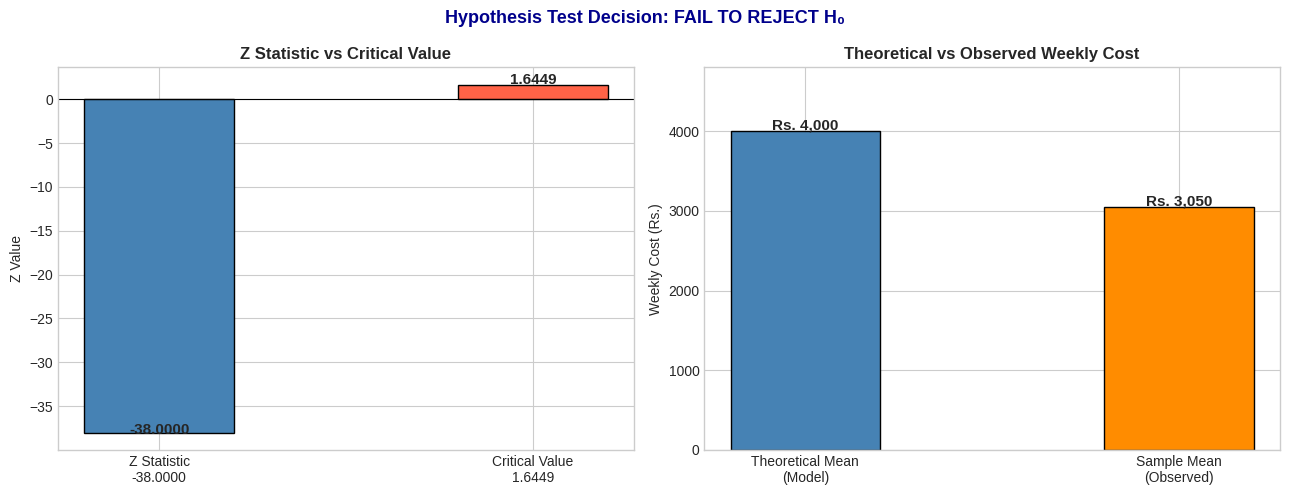

In [9]:
# Visual summary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar: Z statistic vs critical value
z_vals = [Z_stat, Z_critical]
z_labels = [f'Z Statistic\n{Z_stat:.4f}', f'Critical Value\n{Z_critical:.4f}']
z_colors = ['darkgreen' if Z_stat > 0 else 'steelblue', 'tomato']
bars = axes[0].bar(z_labels, z_vals, color=z_colors, edgecolor='black', width=0.4)
for bar, v in zip(bars, z_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 (bar.get_height() + 0.05) if v >= 0 else (bar.get_height() - 0.15),
                 f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Z Statistic vs Critical Value', fontweight='bold')
axes[0].set_ylabel('Z Value')

# Cost comparison bar
cost_labels = ['Theoretical Mean\n(Model)', 'Sample Mean\n(Observed)']
cost_vals   = [mu_theoretical, x_bar]
cost_colors = ['steelblue', 'darkorange']
bars2 = axes[1].bar(cost_labels, cost_vals, color=cost_colors, edgecolor='black', width=0.4)
for bar, v in zip(bars2, cost_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'Rs. {v:,}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Theoretical vs Observed Weekly Cost', fontweight='bold')
axes[1].set_ylabel('Weekly Cost (Rs.)')
axes[1].set_ylim(0, max(cost_vals) * 1.2)

decision_text = 'REJECT H₀' if reject else 'FAIL TO REJECT H₀'
plt.suptitle(f'Hypothesis Test Decision: {decision_text}',
             fontsize=13, fontweight='bold',
             color='darkred' if reject else 'darkblue')
plt.tight_layout()
plt.show()

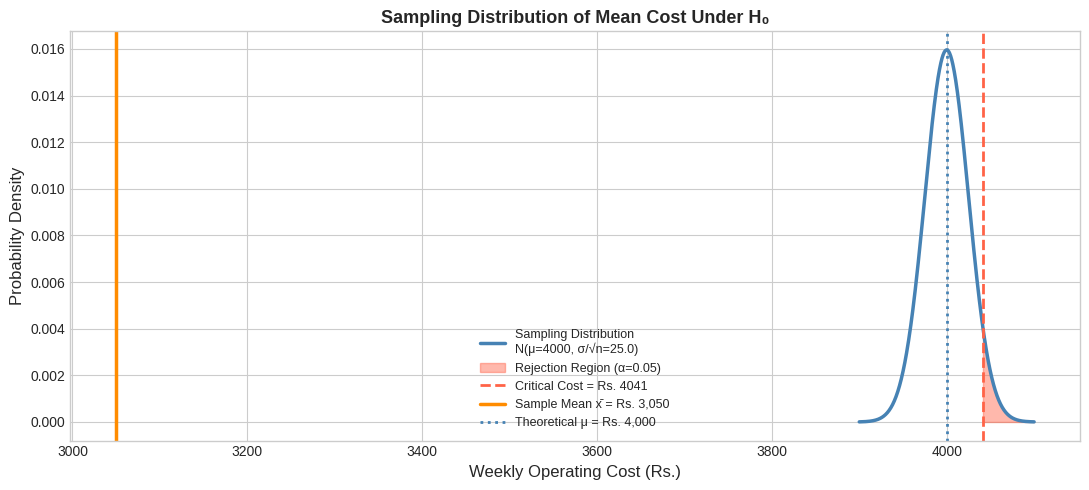

In [10]:
# Sampling distribution of mean cost under H₀
se_plot = sigma_W / np.sqrt(n)
x_cost  = np.linspace(mu_theoretical - 4*se_plot, mu_theoretical + 4*se_plot, 500)
y_cost  = stats.norm.pdf(x_cost, loc=mu_theoretical, scale=se_plot)

crit_cost = mu_theoretical + Z_critical * se_plot

plt.figure(figsize=(11, 5))
plt.plot(x_cost, y_cost, color='steelblue', linewidth=2.5,
         label=f'Sampling Distribution\nN(μ={mu_theoretical}, σ/√n={se_plot:.1f})')

x_rej_cost = x_cost[x_cost >= crit_cost]
plt.fill_between(x_rej_cost, stats.norm.pdf(x_rej_cost, mu_theoretical, se_plot),
                 alpha=0.45, color='tomato', label=f'Rejection Region (α={alpha})')

plt.axvline(crit_cost, color='tomato', linestyle='--', linewidth=2,
            label=f'Critical Cost = Rs. {crit_cost:.0f}')
plt.axvline(x_bar, color='darkorange', linestyle='-', linewidth=2.5,
            label=f'Sample Mean x̄ = Rs. {x_bar:,}')
plt.axvline(mu_theoretical, color='steelblue', linestyle=':', linewidth=2,
            label=f'Theoretical μ = Rs. {mu_theoretical:,}')

plt.xlabel('Weekly Operating Cost (Rs.)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Sampling Distribution of Mean Cost Under H₀', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Summary Report

| Step | Detail | Value |
|---|---|---|
| Cost Model | W = 1,000 + 5X | — |
| H₀ | μ = Rs. 4,000 (theoretical cost at X=600) | — |
| H₁ | μ > Rs. 4,000 (owners claim costs are higher) | — |
| Test Type | One-tailed right Z-test | — |
| Theoretical Mean (μ) | 1,000 + 5×600 | Rs. 4,000 |
| Sample Mean (x̄) | Given | Rs. 3,050 |
| Std Dev of Cost (σ_W) | 5 × 25 | Rs. 125 |
| Standard Error (SE) | σ_W / √n = 125 / √25 | 25.0 |
| Z Statistic | (3050 − 4000) / 25 | **−38.0** |
| Critical Value | Z(α=0.05, right tail) | 1.6449 |
| P-value | 1 − Φ(−38) | ≈ 1.000 |
| Decision | Z (−38) ≤ Z_crit (1.6449) | **Fail to Reject H₀** |

**Conclusion:**  
At the 5% significance level, we **fail to reject H₀**. The sample mean weekly cost of Rs. 3,050 is actually **below** the theoretical model cost of Rs. 4,000. The observed data does not support the restaurant owners' claim that weekly operating costs are higher than the model predicts. The Z-statistic of −38 falls far to the left, entirely outside the right-tail rejection region.

**Note:** The negative Z-statistic suggests the observed costs are substantially lower than the model, not higher. This contradicts the direction of the owners' claim. If the intent was to test whether costs **differ** from the model (two-tailed), or if there is a unit discrepancy (Rs. vs \$), a revised problem setup would be needed.